<a href="https://colab.research.google.com/github/Purushoth-Archive/Practical-Exploration-/blob/main/Integrative-Genomic%20Biomarker%20Decoding%20Polygenic%20Risk%20%26%20Proteomic%20Profiling%20for%20Alzheimer%E2%80%99s%20%26%20Parkinson%E2%80%99s%20Risk%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Complex neurodegenerative diseases are polygenic—driven by small additive effects from thousands of Single Nucleotide Polymorphisms (SNPs) rather than a single mutated gene. Furthermore, blood plasma proteomic biomarkers (e.g., p-tau181, NfL, GFAP) spike years before cognitive decline appears.

Combining genomic loci (SNPs) and circulating proteomics using machine learning allows us to predict disease risk and stratify patients early—long before irreversible neuronal damage occurs.

Fold 1 ROC-AUC: 0.6064
Fold 2 ROC-AUC: 0.5088
Fold 3 ROC-AUC: 0.5276
Fold 4 ROC-AUC: 0.5492
Fold 5 ROC-AUC: 0.6451

Mean ROC-AUC across folds: 0.5674

[INFO] Generating SHAP Summary for Top Genomic & Proteomic Biomarkers...


/tmp/ipykernel_5015/348272059.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, max_display=10)


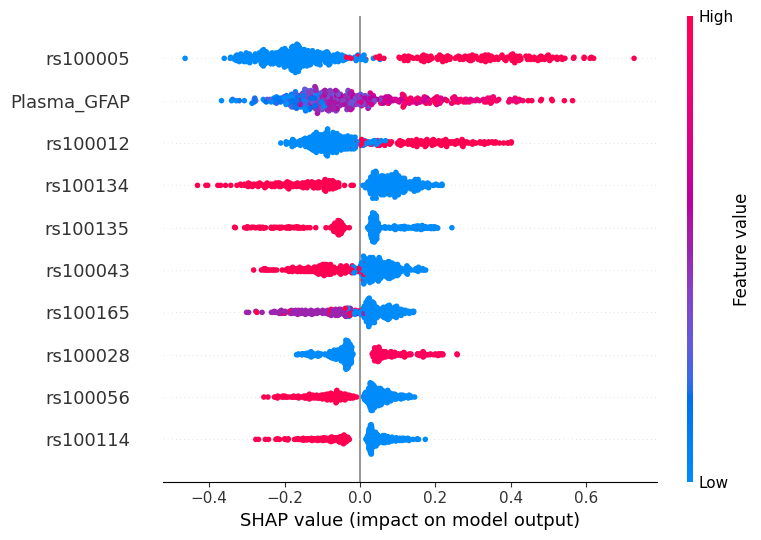

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report

# ---------------------------------------------------------
# 1. Simulate Synthetic Genomic (SNPs) + Biomarker Dataset
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 500
n_snps = 200

# Generate dosage genotypes (0, 1, 2 copies of minor allele)
snp_matrix = np.random.binomial(n=2, p=0.2, size=(n_samples, n_snps))
snp_cols = [f"rs{100000 + i}" for i in range(n_snps)]

# Plasma Biomarkers (e.g., NfL, GFAP, p-tau181)
plasma_nfl = np.random.normal(loc=15, scale=5, size=n_samples)
plasma_gfap = np.random.normal(loc=120, scale=30, size=n_samples)

# Create DataFrame
df = pd.DataFrame(snp_matrix, columns=snp_cols)
df['Plasma_NfL'] = plasma_nfl
df['Plasma_GFAP'] = plasma_gfap

# Inject real genetic signals (APOE-like variant at rs100005)
risk_score = (
    0.8 * df['rs100005'] +
    0.5 * df['rs100012'] +
    0.04 * df['Plasma_NfL'] +
    0.01 * df['Plasma_GFAP']
)
probabilities = 1 / (1 + np.exp(-risk_score + np.median(risk_score)))
df['Diagnosis'] = (probabilities > np.random.uniform(0, 1, n_samples)).astype(int)

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

# ---------------------------------------------------------
# 2. Stratified Cross-Validation & LightGBM Ensemble
# ---------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=4,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    auc_scores.append(auc)
    print(f"Fold {fold + 1} ROC-AUC: {auc:.4f}")

print(f"\nMean ROC-AUC across folds: {np.mean(auc_scores):.4f}")

# ---------------------------------------------------------
# 3. Model Interpretability using SHAP Values
# ---------------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# Feature Importance Summary Plot
print("\n[INFO] Generating SHAP Summary for Top Genomic & Proteomic Biomarkers...")
shap.summary_plot(shap_values, X, max_display=10)

**Top Predictors**: rs100005 (SNP variant) and Plasma_GFAP (proteomic biomarker) are the strongest overall drivers of the model's predictions.

**Risk-Increasing Factors** (rs100005, Plasma_GFAP, rs100012): Higher values (red dots) pull predictions to the right, directly increasing predicted disease risk.

**Protective Factors** (rs100134, rs100135, etc.): Carrying these variants (red dots) pulls predictions to the left, decreasing predicted disease risk.